# Sampling and Uncertainty

## Setup: Load Libraries

Install any missing packages before running locally:
```r
install.packages(c("tidyverse","lubridate", "scales", "openintro", "tidymodels"))
```
these packages are pre-installed in Jupyter Hub.

In [18]:
suppressPackageStartupMessages({

library(dplyr)
library(forcats) # for forcats::fct_relevel() and forcats::fct_rev()
library(ggplot2)
# or just load instead of all of the above
# library(tidyverse)
})

# not in tidyverse:
library(scales) # for scales::label_percent()

---
## Part 1: Catalan Independence Survey — Visualizing Uncertainty

On December 19, 2014, Spanish newspaper *El País* reported on a Catalan independence survey.
These plots illustrate how ignoring the margin of error can be misleading.

In [19]:
# Create the Catalan survey data
catalan <- tibble(
  response = c("No", "Yes", "No answer"),
  rate     = c(45.3, 44.5, 10.2)
) |>
  mutate(response = fct_relevel(response, "No", "Yes", "No answer"))

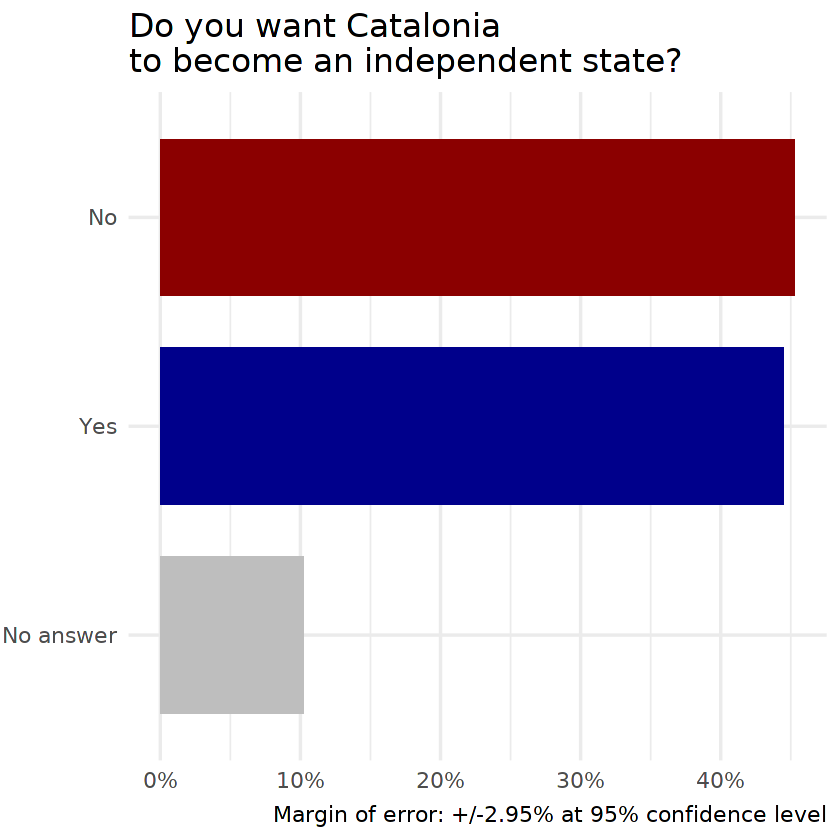

In [35]:
# Misleading bar chart (ignores margin of error)
ggplot(catalan, aes(y = fct_rev(response), x = rate, fill = response)) +
  geom_col(width = .75) +
  scale_fill_manual(values = c("darkred", "blue4", "gray")) +
  scale_x_continuous(labels = label_percent(scale = 1)) +
  theme_minimal(base_size = 16) +
  labs(
    title = "Do you want Catalonia\nto become an independent state?",
    caption = "Margin of error: +/-2.95% at 95% confidence level",
    x = NULL, y = NULL) +
  theme(legend.position = "none") 

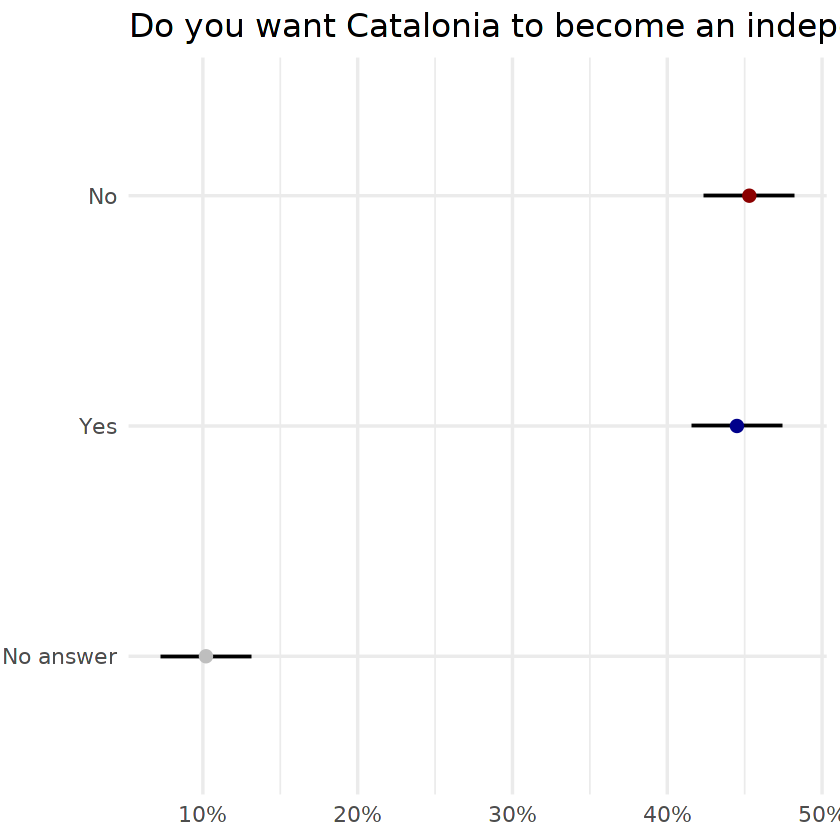

In [36]:
# Add margin of error bounds
catalan <- catalan |>
  mutate(
    low  = rate - 2.95,
    high = rate + 2.95
  )

# Better chart: shows confidence intervals
ggplot(catalan, aes(y = fct_rev(response), x = rate, color = response, group = response)) +
  geom_segment(aes(x = low, xend = high,
                   y = fct_rev(response), yend = fct_rev(response)),
               linewidth = 0.8, color = "black") +
  geom_point(size = 3) +
  scale_color_manual(values = c("darkred", "blue4", "gray")) +
  scale_x_continuous(labels = label_percent(scale = 1)) +
  guides(color = "none") +
  theme_minimal(base_size = 16) +
  labs(
    title = "Do you want Catalonia to become an independent state?",
    x = NULL, y = NULL 
  )

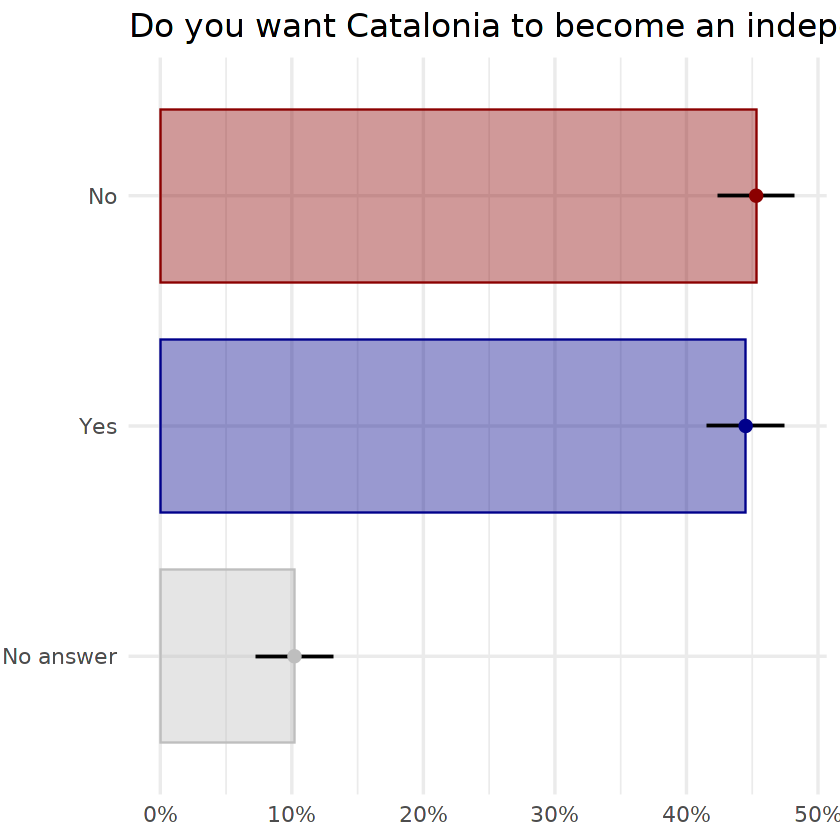

In [37]:
catalan <- catalan |>
  mutate(low = rate - 2.95, high = rate + 2.95)

ggplot(catalan, aes(y = fct_rev(response), x = rate, fill = response, color = response)) +
  geom_col(width = .75, alpha = 0.4) +
  geom_segment(aes(x = low, xend = high,
                   y = fct_rev(response), yend = fct_rev(response)),
               linewidth = 0.8, color = "black") +
  geom_point(size = 3) +
  scale_fill_manual(values = c("darkred", "blue4", "gray")) +
  scale_color_manual(values = c("darkred", "blue4", "gray")) +
  scale_x_continuous(labels = label_percent(scale = 1)) +
  guides(fill = "none", color = "none") +
  theme_minimal(base_size = 16) +
  labs(
    title = "Do you want Catalonia to become an independent state?",
    x = NULL, y = NULL
  )


---
## Part 2: Russian Influence Survey — Exploring the Data

Pew Research survey of 506 Russians: do they believe Russia interfered in the 2016 US presidential election?

Data is available in the `openintro` package.

In [38]:
library(openintro)

glimpse(russian_influence_on_us_election_2016)

Rows: 506
Columns: 1
$ influence_2016 <chr> "Did not try", "Did not try", "Did not try", "Don't kno…


In [39]:
# Recode qualitative variable as numeric (0/1)
russiaData <- russian_influence_on_us_election_2016 |>
  mutate(try_influence = ifelse(influence_2016 == "Did try", 1, 0))

In [40]:
# Calculate mean and standard deviation
russiaData |>
  summarize(
    mean = mean(try_influence),
    sd   = sd(try_influence)
  )

mean,sd
<dbl>,<dbl>
0.1501976,0.3576186


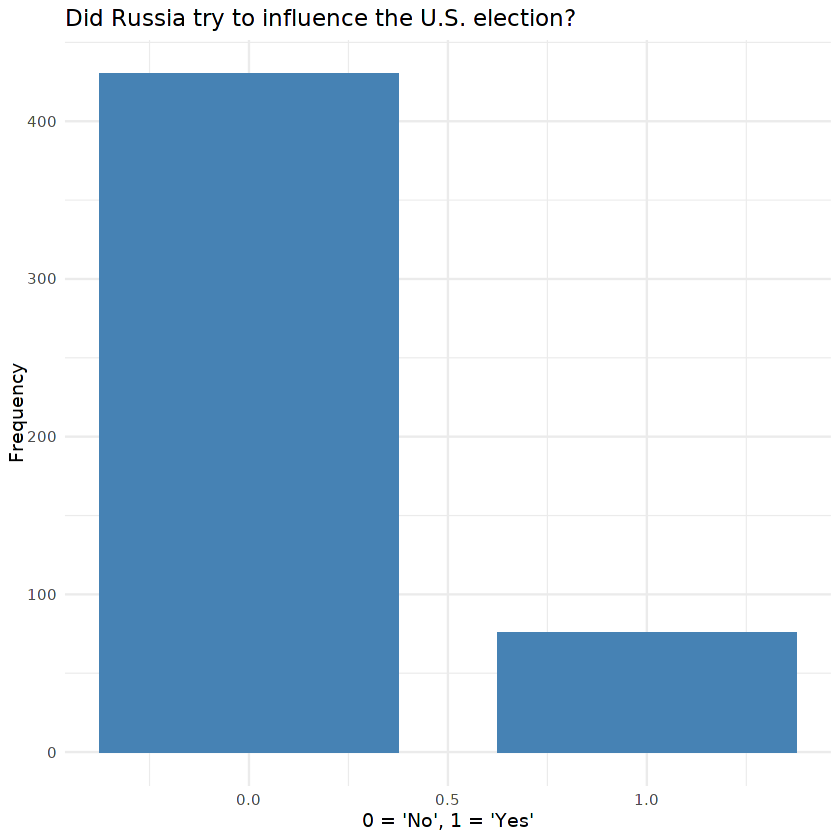

In [41]:
# Bar plot of responses
ggplot(russiaData, aes(x = try_influence)) +
  geom_bar(fill = "steelblue", width = .75) +
  labs(
    title = "Did Russia try to influence the U.S. election?",
    x = "0 = 'No', 1 = 'Yes'",
    y = "Frequency"
  ) +
  theme_minimal()

---
## Part 3: Bootstrapping with `tidymodels`

Use bootstrapping (nonparametric resampling) to estimate a 95% confidence interval for the proportion.

In [42]:
library(infer) # 'infer' included with 'tidymodels'
# library(tidymodels) # full group of libraries (similar to tidyverse)


set.seed(66)
boot_dist <- russiaData |>
  specify(response = try_influence) |>           # specify the variable of interest
  generate(reps = 10000, type = "bootstrap") |>  # generate 10000 bootstrap samples
  calculate(stat = "mean")                       # calculate the mean of each bootstrap sample

glimpse(boot_dist)

Rows: 10,000
Columns: 2
$ replicate <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1…
$ stat      <dbl> 0.1146245, 0.1442688, 0.1343874, 0.1877470, 0.1521739, 0.138…


In [43]:
# Mean of the bootstrap distribution
boot_dist |> summarize(mean = mean(stat))

mean
<dbl>
0.1502773


In [44]:
# 95% confidence interval (middle 95% of bootstrap distribution)
boot_dist |>
  summarize(
    lower = quantile(stat, 0.025),
    upper = quantile(stat, 0.975)
  )

lower,upper
<dbl>,<dbl>
0.1185771,0.1818182


In [45]:
# Store bounds for visualization
lower_bound <- boot_dist |> summarize(lower_bound = quantile(stat, 0.025)) |> pull()
upper_bound <- boot_dist |> summarize(upper_bound = quantile(stat, 0.975)) |> pull()

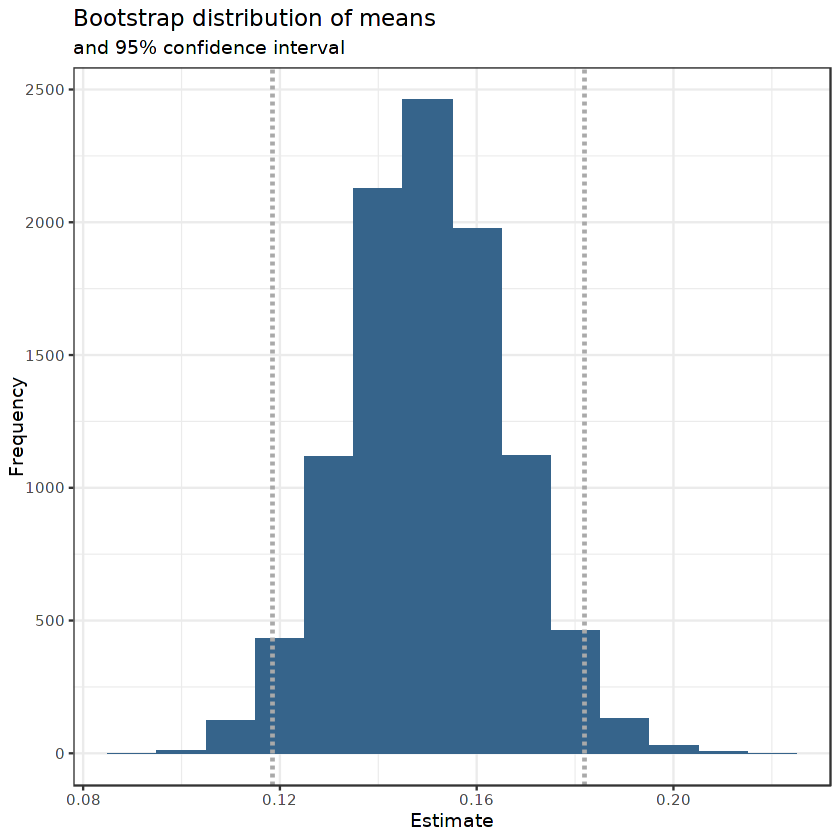

In [46]:
# Histogram of bootstrap distribution with CI bounds
ggplot(data = boot_dist, mapping = aes(x = stat)) +
  geom_histogram(binwidth = .01, fill = "steelblue4") +
  geom_vline(xintercept = c(lower_bound, upper_bound),
             color = "darkgrey", linewidth = 1, linetype = "dashed") +
  labs(
    title    = "Bootstrap distribution of means",
    subtitle = "and 95% confidence interval",
    x = "Estimate",
    y = "Frequency"
  ) +
  theme_bw()

---
## Part 4: Using the `infer` Package

In [47]:
# Get confidence interval with infer::get_ci()
ci <- boot_dist |> get_ci(level = 0.95)
ci

lower_ci,upper_ci
<dbl>,<dbl>
0.1185771,0.1818182


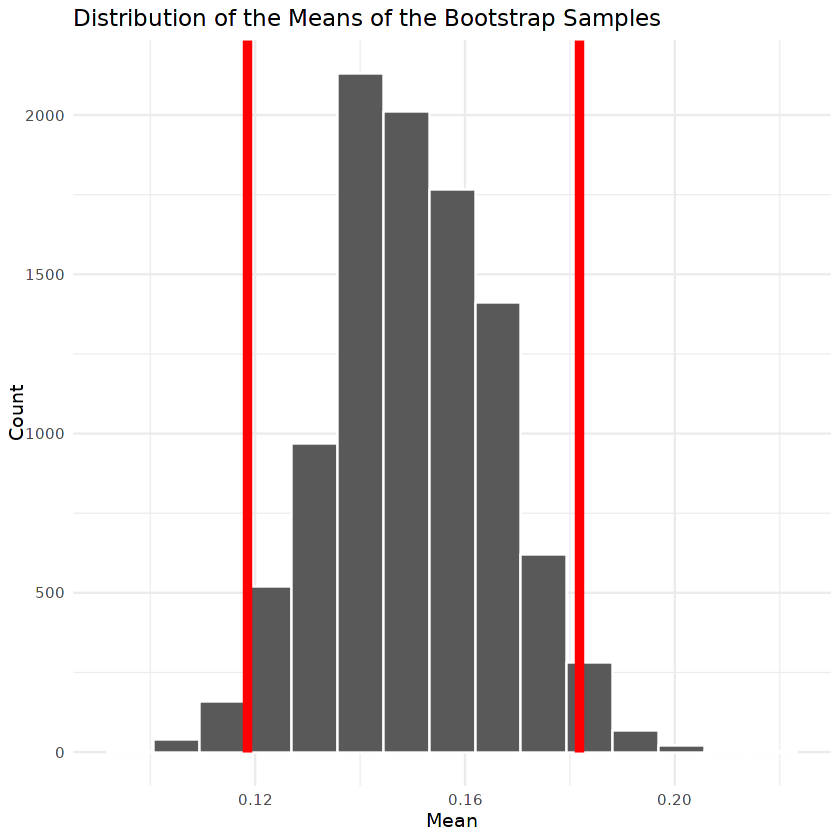

In [48]:
# Visualize bootstrap distribution with shaded CI
boot_dist |>
  visualize() +
  shade_ci(ci, color = "red", fill = NULL) +
  labs(
    title = "Distribution of the Means of the Bootstrap Samples",
    x = "Mean",
    y = "Count"
  ) +
  theme_minimal()

---
## Part 5: Try It Out — Math-Based Confidence Interval

Use the formula below to estimate the confidence interval from the sample of 506 Russians.

Since the data is 0/1 encoded, the mean equals the proportion $\hat{p}$.

$$SE = \sqrt{\frac{\hat{p}(1 - \hat{p})}{n}}$$

$$CI = \hat{p} \pm 1.96 \times SE$$

Tips:
- To count rows: `nrow(your_data)`
- To access a column: `your_data$col_name`

In [49]:
# Your turn: compute a math-based 95% CI for the proportion
p_hat <- mean(russiaData$try_influence)
n     <- nrow(russiaData)
se    <- sqrt(p_hat * (1 - p_hat) / n)

ci_lower <- p_hat - 1.96 * se
ci_upper <- p_hat + 1.96 * se

cat(sprintf("p-hat: %.4f\nSE: %.4f\n95%% CI: (%.4f, %.4f)\n",
            p_hat, se, ci_lower, ci_upper))

p-hat: 0.1502
SE: 0.0159
95% CI: (0.1191, 0.1813)
